# Trump Tweets Classification - Exploratory Data Analysis

This notebook performs exploratory data analysis on the Trump tweets dataset for authorship attribution.

## Objectives
1. Load and examine the training dataset
2. Analyze data distribution (Trump vs Staffer tweets)
3. Examine tweet lengths, patterns, and characteristics
4. Check for missing values and data quality issues
5. Analyze temporal patterns (time of tweeting)

In [24]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Load and Examine Dataset

In [25]:
# Load the training dataset
data_path = '../data/trump_train.tsv'
df = pd.read_csv(data_path, sep='\t', header=None, names=['tweet_id', 'user_handle', 'tweet_text', 'timestamp', 'device'])

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst few rows:")
df.head()

Dataset shape: (3156, 5)
Columns: ['tweet_id', 'user_handle', 'tweet_text', 'timestamp', 'device']

First few rows:


,tweet_id,user_handle,tweet_text,timestamp,device
0,845974102619906048,realDonaldTrump,Democrats are smiling in D.C. that the Freedom...,2017-03-26 15:21:58,iphone
1,846166053663191040,realDonaldTrump,General Kelly is doing a great job at the bord...,2017-03-27 04:04:42,iphone
2,835814988686233601,realDonaldTrump,"The race for DNC Chairman was, of course, tota...",2017-02-26 13:33:16,android
3,835817351178301440,realDonaldTrump,For first time the failing @nytimes will take ...,2017-02-26 13:42:39,android
4,835916511944523777,realDonaldTrump,"Russia talk is FAKE NEWS put out by the Dems, ...",2017-02-26 20:16:41,android


In [26]:
# Basic dataset information
print("Dataset Info:")
df.info()
print("\nDataset Description:")
df.describe(include='all')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3156 entries, 0 to 3155
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   tweet_id     3156 non-null   int64 
 1   user_handle  3156 non-null   object
 2   tweet_text   3156 non-null   object
 3   timestamp    3156 non-null   object
 4   device       3156 non-null   object
dtypes: int64(1), object(4)
memory usage: 123.4+ KB

Dataset Description:


,tweet_id,user_handle,tweet_text,timestamp,device
count,3.156000e+03,3156,3156,3156,3156
unique,NaN,3,3149,3136,9
top,NaN,realDonaldTrump,MAKE AMERICA GREAT AGAIN!,otherTwitter for,android
freq,NaN,3144,3,18,1991
mean,7.072638e+17,NaN,NaN,NaN,NaN
std,5.351963e+16,NaN,NaN,NaN,NaN
min,5.931708e+17,NaN,NaN,NaN,NaN
25%,6.639595e+17,NaN,NaN,NaN,NaN
50%,7.003111e+17,NaN,NaN,NaN,NaN
75%,7.481636e+17,NaN,NaN,NaN,NaN


## 2. Data Quality Check

In [27]:
# Check for missing values
print("Missing values per column:")
missing_values = df.isnull().sum()
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")
print(f"Percentage of missing values: {(missing_values.sum() / len(df)) * 100:.2f}%")

Missing values per column:
tweet_id       0
user_handle    0
tweet_text     0
timestamp      0
device         0
dtype: int64

Total missing values: 0
Percentage of missing values: 0.00%


In [28]:
# Check for duplicates
print(f"Number of duplicate rows: {df.duplicated().sum()}")
print(f"Number of duplicate tweets (by text): {df.duplicated(subset=['tweet_text']).sum()}")
print(f"Number of duplicate tweet IDs: {df.duplicated(subset=['tweet_id']).sum()}")

Number of duplicate rows: 0
Number of duplicate tweets (by text): 7
Number of duplicate tweet IDs: 0


## 3. Analyze User Handles and Devices

User handle distribution:
user_handle
realDonaldTrump    3144
PressSec             11
POTUS                 1
Name: count, dtype: int64

Unique user handles: 3


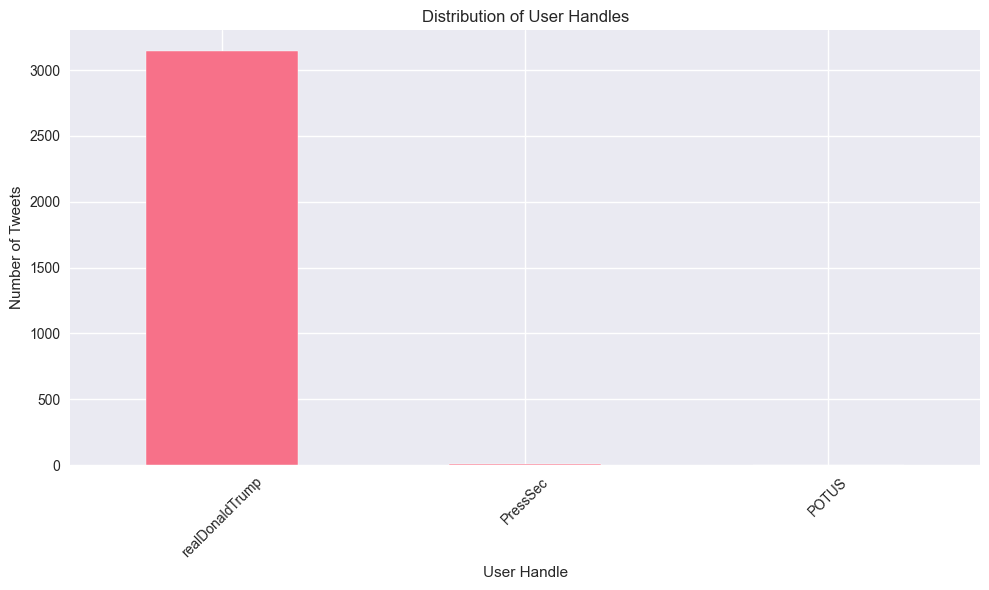

In [29]:
# Analyze user handles
print("User handle distribution:")
handle_counts = df['user_handle'].value_counts()
print(handle_counts)
print(f"\nUnique user handles: {df['user_handle'].nunique()}")

# Visualize user handle distribution
plt.figure(figsize=(10, 6))
handle_counts.plot(kind='bar')
plt.title('Distribution of User Handles')
plt.xlabel('User Handle')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Device distribution:
device
android                  1991
iphone                    906
webClient                 225
BlackBerry</a>             12
tweetDeck                   8
iPad</a>                    6
instagram                   4
otherPeriscope.TV</a>       3
otherFacebook</a>           1
Name: count, dtype: int64

Unique devices: 9


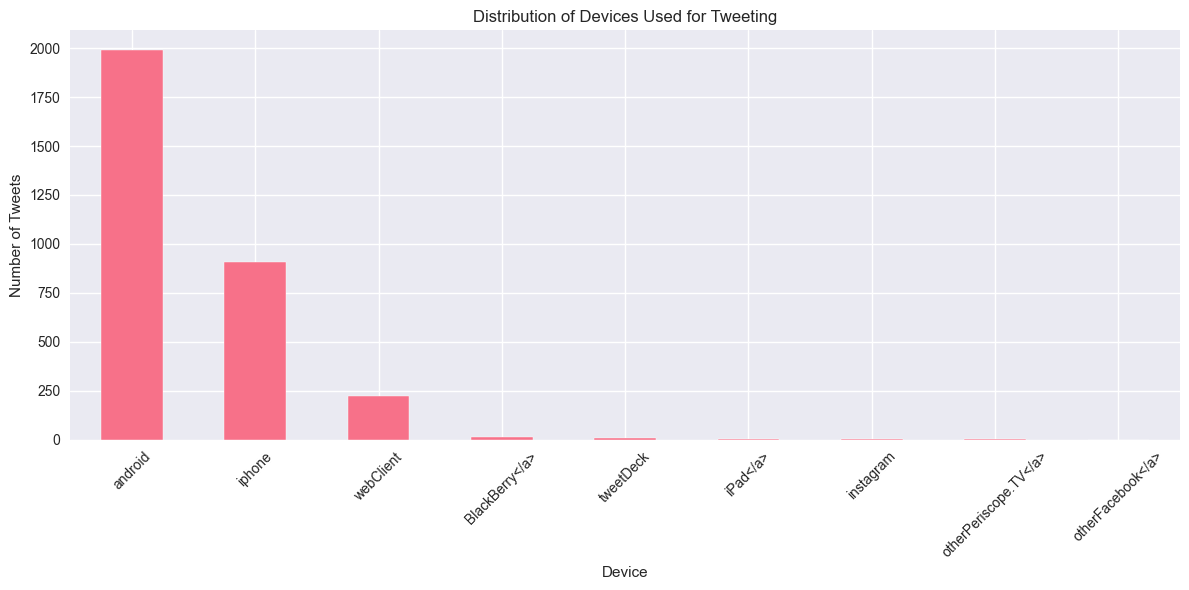

In [30]:
# Analyze device types
print("Device distribution:")
device_counts = df['device'].value_counts()
print(device_counts)
print(f"\nUnique devices: {df['device'].nunique()}")

# Visualize device distribution
plt.figure(figsize=(12, 6))
device_counts.plot(kind='bar')
plt.title('Distribution of Devices Used for Tweeting')
plt.xlabel('Device')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Create Binary Labels for Classification

In [31]:
# Create binary labels based on device
# 0 = Trump (Android), 1 = Staffer (iPhone/other)
def create_labels(device):
    if 'android' in device.lower():
        return 0  # Trump
    else:
        return 1  # Staffer

df['label'] = df['device'].apply(create_labels)

# Analyze label distribution
print("Label distribution:")
label_counts = df['label'].value_counts()
print(f"Trump (Android) tweets: {label_counts[0]} ({label_counts[0]/len(df)*100:.1f}%)")
print(f"Staffer (iPhone/other) tweets: {label_counts[1]} ({label_counts[1]/len(df)*100:.1f}%)")
print(f"\nClass balance ratio: {label_counts[0]/label_counts[1]:.2f}")

Label distribution:
Trump (Android) tweets: 1991 (63.1%)
Staffer (iPhone/other) tweets: 1165 (36.9%)

Class balance ratio: 1.71


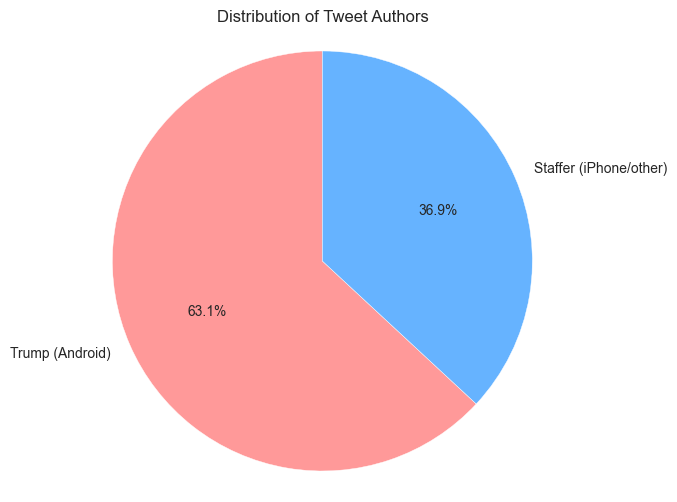

In [32]:
# Visualize label distribution
plt.figure(figsize=(8, 6))
labels = ['Trump (Android)', 'Staffer (iPhone/other)']
colors = ['#ff9999', '#66b3ff']
plt.pie(label_counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Tweet Authors')
plt.axis('equal')
plt.show()

## 5. Temporal Analysis

In [33]:
# First, let's examine the timestamp format to identify issues
print("Sample timestamp values:")
print(df['timestamp'].head(10))
print("\nTimestamp value counts (top 10):")
print(df['timestamp'].value_counts().head(10))

# Check for problematic entries
print("\nChecking for non-datetime entries:")
import re
date_pattern = r'^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2}$'
valid_timestamps = df['timestamp'].str.match(date_pattern, na=False)
problematic = df[~valid_timestamps]
print(f"Number of problematic entries: {len(problematic)}")

if len(problematic) > 0:
    print("\nProblematic timestamp entries:")
    print(problematic[['timestamp', 'device']].head(10))
    
    # Let's see what devices have problematic timestamps
    print("\nDevice distribution for problematic timestamps:")
    print(problematic['device'].value_counts())

# Create cleaned dataframe for temporal analysis
df_clean = df[valid_timestamps].copy()
print(f"\nFiltered dataset for temporal analysis: {len(df_clean)} rows (removed {len(df) - len(df_clean)} problematic entries)")

# Parse timestamps for clean data
df_clean['datetime'] = pd.to_datetime(df_clean['timestamp'], errors='coerce')
df_clean['hour'] = df_clean['datetime'].dt.hour
df_clean['day_of_week'] = df_clean['datetime'].dt.day_name()
df_clean['month'] = df_clean['datetime'].dt.month
df_clean['year'] = df_clean['datetime'].dt.year

print("\nTemporal range for valid timestamps:")
print(f"From: {df_clean['datetime'].min()}")
print(f"To: {df_clean['datetime'].max()}")
print(f"Span: {(df_clean['datetime'].max() - df_clean['datetime'].min()).days} days")

# Check label distribution in clean data
print(f"\nLabel distribution in clean data:")
clean_label_counts = df_clean['label'].value_counts()
print(f"Trump (Android) tweets: {clean_label_counts[0]} ({clean_label_counts[0]/len(df_clean)*100:.1f}%)")
print(f"Staffer (iPhone/other) tweets: {clean_label_counts[1]} ({clean_label_counts[1]/len(df_clean)*100:.1f}%)")

Sample timestamp values:
0    2017-03-26 15:21:58
1    2017-03-27 04:04:42
2    2017-02-26 13:33:16
3    2017-02-26 13:42:39
4    2017-02-26 20:16:41
5    2017-02-26 22:13:52
6    2017-01-14 14:50:26
7    2017-01-14 15:07:12
8    2017-01-14 15:14:13
9    2017-01-15 02:22:01
Name: timestamp, dtype: object

Timestamp value counts (top 10):
timestamp
otherTwitter for                  18
<a href="https://periscope.tv"     3
2016-01-14 07:45:41                2
2016-06-13 14:40:05                1
2016-06-13 14:22:40                1
2016-10-15 14:45:58                1
2016-10-15 15:17:06                1
2016-07-13 07:54:40                1
2016-06-13 17:59:25                1
2016-07-13 15:33:15                1
Name: count, dtype: int64

Checking for non-datetime entries:
Number of problematic entries: 22

Problematic timestamp entries:
                                      timestamp                 device
223                            otherTwitter for         BlackBerry</a>
245       

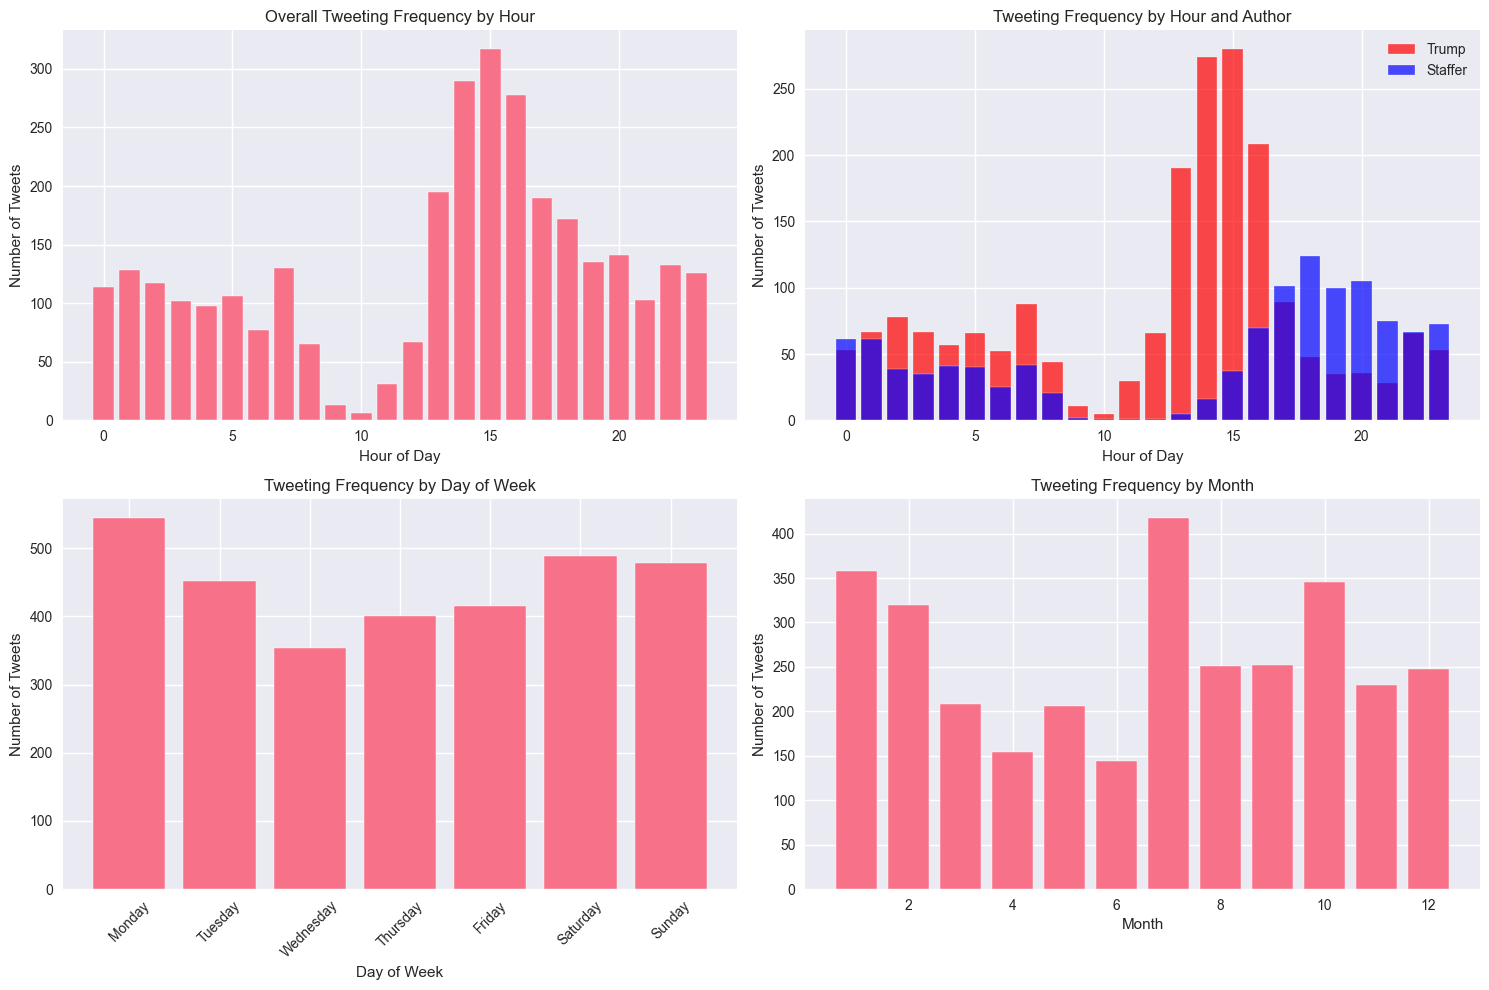

In [34]:
# Analyze tweeting patterns by hour using cleaned data
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Overall hourly distribution
hourly_counts = df_clean['hour'].value_counts().sort_index()
axes[0, 0].bar(hourly_counts.index, hourly_counts.values)
axes[0, 0].set_title('Overall Tweeting Frequency by Hour')
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Number of Tweets')

# Hourly distribution by author
trump_hours = df_clean[df_clean['label'] == 0]['hour'].value_counts().sort_index()
staffer_hours = df_clean[df_clean['label'] == 1]['hour'].value_counts().sort_index()

axes[0, 1].bar(trump_hours.index, trump_hours.values, alpha=0.7, label='Trump', color='red')
axes[0, 1].bar(staffer_hours.index, staffer_hours.values, alpha=0.7, label='Staffer', color='blue')
axes[0, 1].set_title('Tweeting Frequency by Hour and Author')
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('Number of Tweets')
axes[0, 1].legend()

# Day of week distribution
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = df_clean['day_of_week'].value_counts().reindex(dow_order)
axes[1, 0].bar(range(len(dow_counts)), dow_counts.values)
axes[1, 0].set_title('Tweeting Frequency by Day of Week')
axes[1, 0].set_xlabel('Day of Week')
axes[1, 0].set_ylabel('Number of Tweets')
axes[1, 0].set_xticks(range(len(dow_counts)))
axes[1, 0].set_xticklabels(dow_counts.index, rotation=45)

# Monthly distribution
monthly_counts = df_clean['month'].value_counts().sort_index()
axes[1, 1].bar(monthly_counts.index, monthly_counts.values)
axes[1, 1].set_title('Tweeting Frequency by Month')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Number of Tweets')

plt.tight_layout()
plt.show()

## 6. Tweet Text Analysis

In [35]:
# Analyze tweet lengths
df['tweet_length'] = df['tweet_text'].str.len()
df['word_count'] = df['tweet_text'].str.split().str.len()

print("Tweet length statistics:")
print(df['tweet_length'].describe())
print("\nWord count statistics:")
print(df['word_count'].describe())

Tweet length statistics:
count    3156.000000
mean      136.098226
std       186.025704
min        14.000000
25%        97.750000
50%       130.000000
75%       138.000000
max      4938.000000
Name: tweet_length, dtype: float64

Word count statistics:
count    3156.000000
mean       20.440114
std        24.745306
min         1.000000
25%        13.000000
50%        19.000000
75%        24.000000
max       673.000000
Name: word_count, dtype: float64


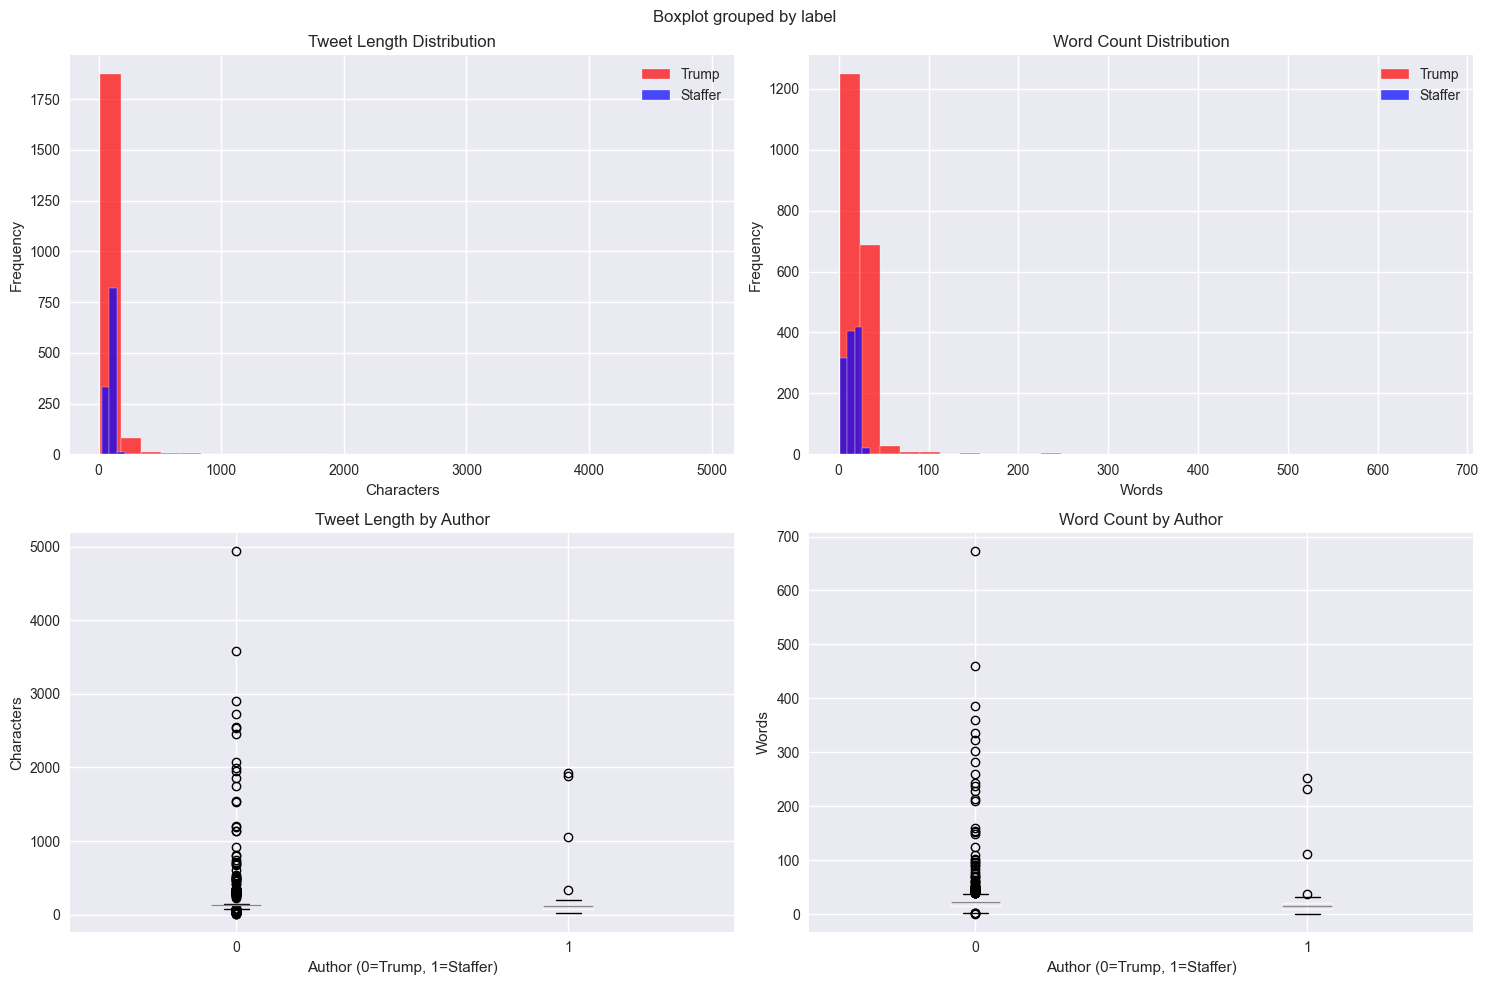

In [36]:
# Compare tweet characteristics by author
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Tweet length distribution
trump_lengths = df[df['label'] == 0]['tweet_length']
staffer_lengths = df[df['label'] == 1]['tweet_length']

axes[0, 0].hist(trump_lengths, bins=30, alpha=0.7, label='Trump', color='red')
axes[0, 0].hist(staffer_lengths, bins=30, alpha=0.7, label='Staffer', color='blue')
axes[0, 0].set_title('Tweet Length Distribution')
axes[0, 0].set_xlabel('Characters')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()

# Word count distribution
trump_words = df[df['label'] == 0]['word_count']
staffer_words = df[df['label'] == 1]['word_count']

axes[0, 1].hist(trump_words, bins=30, alpha=0.7, label='Trump', color='red')
axes[0, 1].hist(staffer_words, bins=30, alpha=0.7, label='Staffer', color='blue')
axes[0, 1].set_title('Word Count Distribution')
axes[0, 1].set_xlabel('Words')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# Box plots for comparison
df.boxplot(column='tweet_length', by='label', ax=axes[1, 0])
axes[1, 0].set_title('Tweet Length by Author')
axes[1, 0].set_xlabel('Author (0=Trump, 1=Staffer)')
axes[1, 0].set_ylabel('Characters')

df.boxplot(column='word_count', by='label', ax=axes[1, 1])
axes[1, 1].set_title('Word Count by Author')
axes[1, 1].set_xlabel('Author (0=Trump, 1=Staffer)')
axes[1, 1].set_ylabel('Words')

plt.tight_layout()
plt.show()

## 7. Stylistic Features Analysis

In [37]:
# Extract stylistic features
def extract_stylistic_features(text):
    features = {}
    
    # Capitalization patterns
    features['caps_count'] = sum(1 for c in text if c.isupper())
    features['caps_ratio'] = features['caps_count'] / len(text) if len(text) > 0 else 0
    
    # Punctuation patterns
    features['exclamation_count'] = text.count('!')
    features['question_count'] = text.count('?')
    features['period_count'] = text.count('.')
    features['comma_count'] = text.count(',')
    
    # Special characters
    features['hashtag_count'] = text.count('#')
    features['mention_count'] = text.count('@')
    features['url_count'] = len(re.findall(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', text))
    
    # Quote patterns
    features['quote_count'] = text.count('"') + text.count("'")
    
    return features

# Apply feature extraction
stylistic_features = df['tweet_text'].apply(extract_stylistic_features)
stylistic_df = pd.DataFrame(stylistic_features.tolist())
stylistic_df['label'] = df['label'].values

print("Stylistic features statistics:")
print(stylistic_df.describe())

Stylistic features statistics:
        caps_count   caps_ratio  exclamation_count  question_count  \
count  3156.000000  3156.000000        3156.000000     3156.000000   
mean     12.169518     0.099135           0.828580        0.063688   
std      16.792613     0.090363           1.143889        0.272454   
min       0.000000     0.000000           0.000000        0.000000   
25%       5.000000     0.044776           0.000000        0.000000   
50%       9.000000     0.074627           1.000000        0.000000   
75%      14.000000     0.124088           1.000000        0.000000   
max     324.000000     0.862069          23.000000        3.000000   

       period_count  comma_count  hashtag_count  mention_count    url_count  \
count   3156.000000  3156.000000    3156.000000    3156.000000  3156.000000   
mean       1.731939     0.653676       0.377376       1.029151     0.381496   
std        2.166685     1.185553       0.851501       1.520001     0.734627   
min        0.000000   

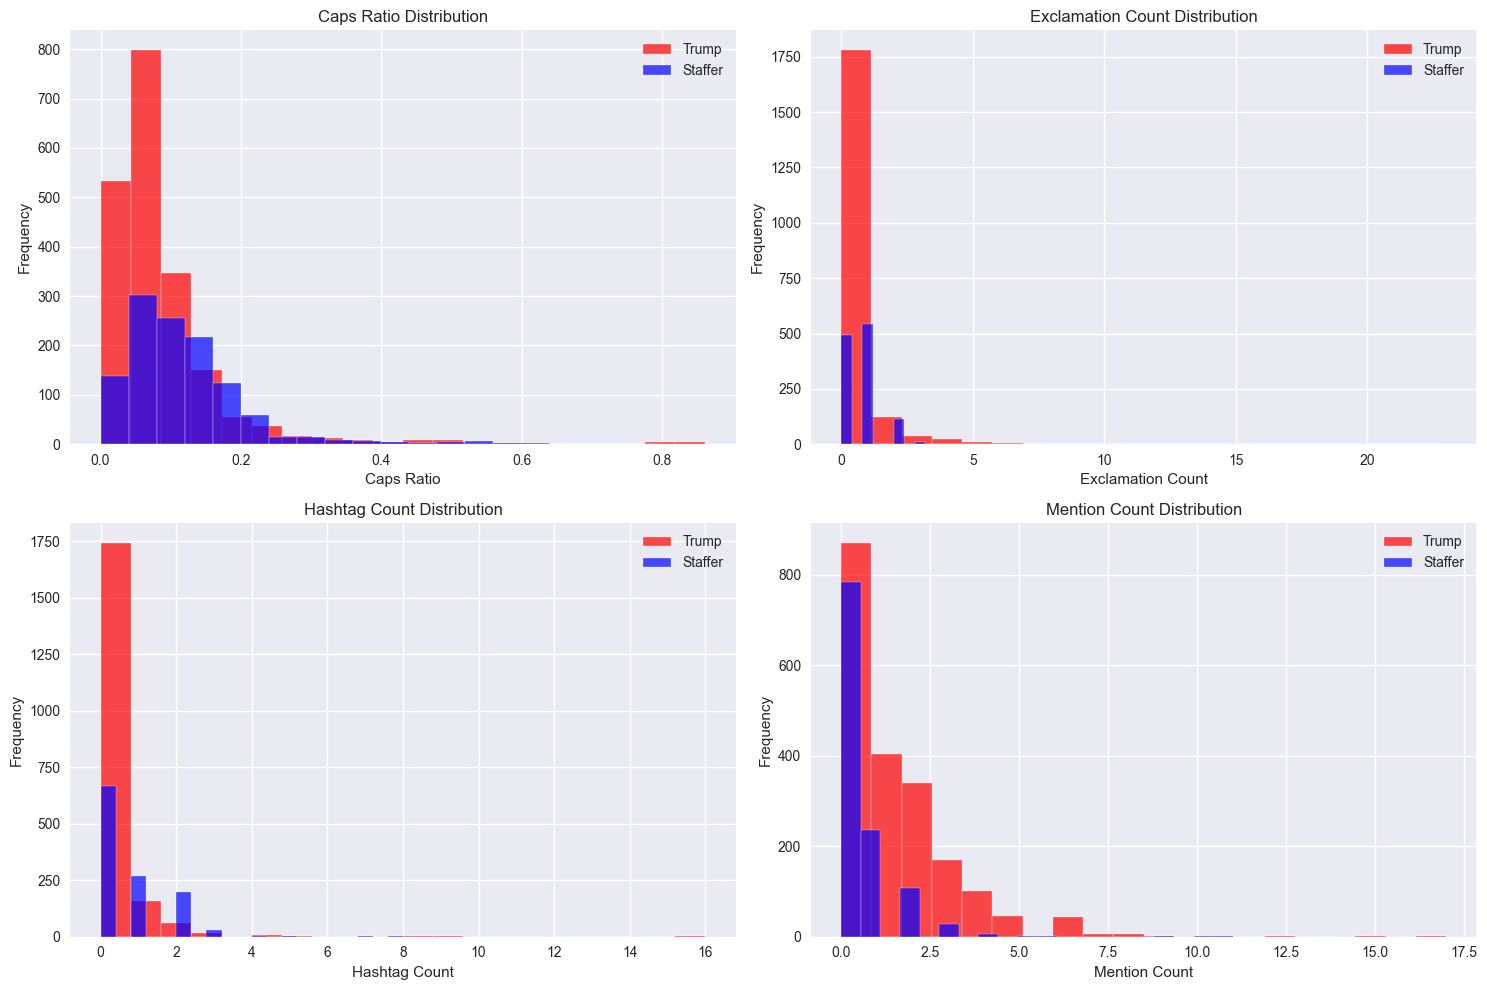

In [38]:
# Compare stylistic features by author
features_to_plot = ['caps_ratio', 'exclamation_count', 'hashtag_count', 'mention_count']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for i, feature in enumerate(features_to_plot):
    trump_feature = stylistic_df[stylistic_df['label'] == 0][feature]
    staffer_feature = stylistic_df[stylistic_df['label'] == 1][feature]
    
    axes[i].hist(trump_feature, bins=20, alpha=0.7, label='Trump', color='red')
    axes[i].hist(staffer_feature, bins=20, alpha=0.7, label='Staffer', color='blue')
    axes[i].set_title(f'{feature.replace("_", " ").title()} Distribution')
    axes[i].set_xlabel(feature.replace('_', ' ').title())
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.tight_layout()
plt.show()

# Create summary statistics by author

In [40]:
# Statistical significance tests
from scipy import stats

trump_data = df[df['label'] == 0]
staffer_data = df[df['label'] == 1]

print("Statistical Significance Tests:")
print("="*40)

# Tweet length difference
t_stat, p_value = stats.ttest_ind(trump_data['tweet_length'], staffer_data['tweet_length'])
print(f"Tweet length difference - t-statistic: {t_stat:.3f}, p-value: {p_value:.6f}")

# Word count difference
t_stat, p_value = stats.ttest_ind(trump_data['word_count'], staffer_data['word_count'])
print(f"Word count difference - t-statistic: {t_stat:.3f}, p-value: {p_value:.6f}")

# Hourly posting patterns
trump_hours = stylistic_df[stylistic_df['label'] == 0]
staffer_hours = stylistic_df[stylistic_df['label'] == 1]

# Exclamation marks
t_stat, p_value = stats.ttest_ind(trump_hours['exclamation_count'], staffer_hours['exclamation_count'])
print(f"Exclamation marks difference - t-statistic: {t_stat:.3f}, p-value: {p_value:.6f}")

Statistical Significance Tests:
Tweet length difference - t-statistic: 6.111, p-value: 0.000000
Word count difference - t-statistic: 9.382, p-value: 0.000000
Exclamation marks difference - t-statistic: 4.148, p-value: 0.000034
